#### Analytics and KPI Calculation
KPIs aligned with typical humanitarian WIM monitoring:
- Stock accuracy & availability
- Expiry & risk exposure
- Compliance performance
- Stock movement efficiency

In [10]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression
from datetime import datetime
import json

#### 1. Load enriched data

In [2]:
df = pd.read_csv('cleaned_enriched_inventory.csv')

date_cols = ['last_received_date', 'last_distributed_date', 'expiry_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print("Loaded shape:", df.shape)
print(df.dtypes)

Loaded shape: (1500, 20)
country                            object
warehouse_id                       object
item_type                          object
item_code                          object
batch_number                       object
stock_level_initial                 int64
stock_level_current                 int64
unit                               object
stock_status                       object
days_on_hand                        int64
last_received_date         datetime64[ns]
last_distributed_date      datetime64[ns]
expiry_date                datetime64[ns]
days_to_expiry                      int64
is_expired                           bool
expiry_urgency_tier                object
condition_flag                     object
donor_compliance_status            object
risk_score                        float64
waybill_reference                  object
dtype: object


#### 2. Global KPIs – Single-value summaries

In [3]:
global_kpis = {
    'Total Items': len(df),
    'Total Current Stock': df['stock_level_current'].sum(),
    'Average Risk Score': round(df['risk_score'].mean(), 1),
    '% Expired': round(df['is_expired'].mean() * 100, 1),
    '% Stockout': round((df['stock_status'] == 'Stockout').mean() * 100, 1),
    '% High Priority or Immediate': round(
        df['expiry_urgency_tier'].isin(['Immediate Action', 'High Priority']).mean() * 100, 1
    ),
    '% Non-Compliant': round(
        df['donor_compliance_status'].str.contains('Non-Compliant').mean() * 100, 1
    ),
    'Average Days on Hand': round(df['days_on_hand'].mean(), 0)
}

print("Global KPIs:")
for k, v in global_kpis.items():
    print(f"{k:35} : {v}")

Global KPIs:
Total Items                         : 1500
Total Current Stock                 : 2687965
Average Risk Score                  : 24.7
% Expired                           : 31.6
% Stockout                          : 0.0
% High Priority or Immediate        : 14.0
% Non-Compliant                     : 16.1
Average Days on Hand                : 118.0


#### 3. Country-level KPI table

In [4]:
country_agg = df.groupby('country').agg(
    Total_Items=('item_code', 'count'),
    Total_Stock=('stock_level_current', 'sum'),
    Avg_Risk_Score=('risk_score', 'mean'),
    Pct_Expired=('is_expired', 'mean'),
    Pct_Stockout=('stock_status', lambda x: (x == 'Stockout').mean()),
    Pct_Near_Expiry_90d=('days_to_expiry', lambda x: ((x > 0) & (x <= 90)).mean()),
    Pct_NonCompliant=('donor_compliance_status', lambda x: x.str.contains('Non-Compliant').mean()),
    Avg_Days_On_Hand=('days_on_hand', 'mean')
).reset_index()

# Format percentages
pct_cols = ['Pct_Expired', 'Pct_Stockout', 'Pct_Near_Expiry_90d', 'Pct_NonCompliant']
country_agg[pct_cols] = (country_agg[pct_cols] * 100).round(1)

print("Country-level KPIs:")
country_agg.round(1)

Country-level KPIs:


,country,Total_Items,Total_Stock,Avg_Risk_Score,Pct_Expired,Pct_Stockout,Pct_Near_Expiry_90d,Pct_NonCompliant,Avg_Days_On_Hand
0,Afghanistan,176,321231,26.3,30.7,0.0,11.9,30.7,118.9
1,Bangladesh,217,374431,22.6,32.7,0.0,12.4,0.0,119.4
2,Ethiopia,462,821562,23.0,32.0,0.0,15.8,0.0,119.0
3,South Sudan,280,508496,25.9,31.4,0.0,12.9,28.6,116.4
4,Yemen,365,662245,26.4,31.0,0.0,14.5,29.6,116.7


#### 4. Visualizations – Interactive Plotly charts

##### Chart 1: Total stock by country

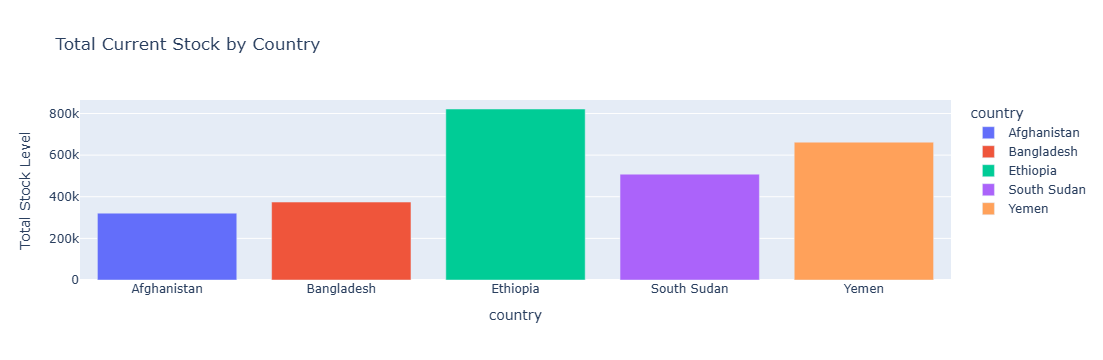

In [5]:
fig_stock = px.bar(
    country_agg,
    x='country',
    y='Total_Stock',
    title='Total Current Stock by Country',
    labels={'Total_Stock': 'Total Stock Level'},
    color='country'
)
fig_stock.show()

##### Chart 2: Risk score by country

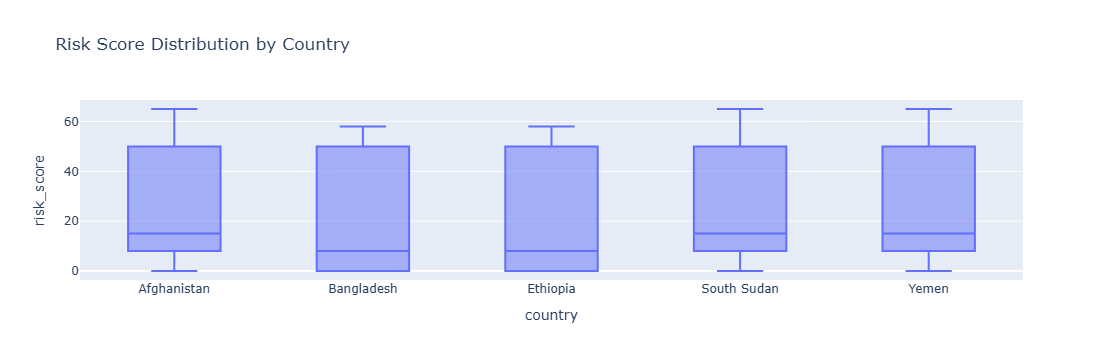

In [6]:
fig_risk = px.box(
    df,
    x='country',
    y='risk_score',
    title='Risk Score Distribution by Country',
    points='outliers'
)
fig_risk.show()

##### Chart 3: Expiry urgency breakdown (pie)

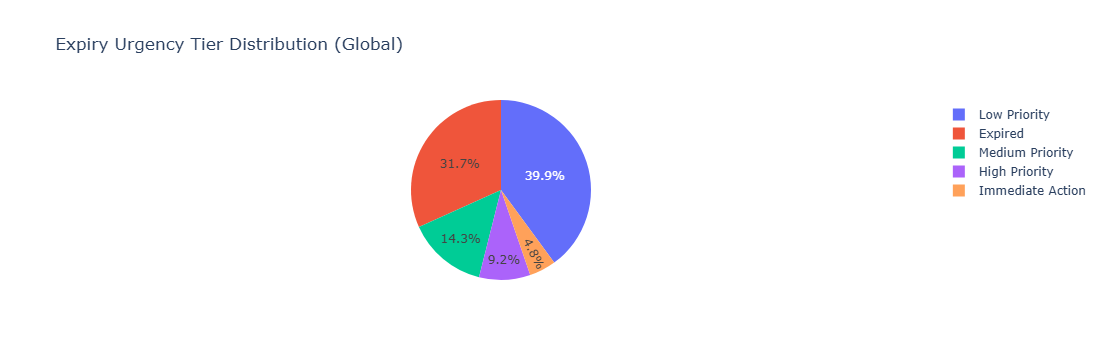

In [7]:
urgency_counts = df['expiry_urgency_tier'].value_counts().reset_index()
urgency_counts.columns = ['Tier', 'Count']
fig_urgency = px.pie(
    urgency_counts,
    values='Count',
    names='Tier',
    title='Expiry Urgency Tier Distribution (Global)'
)
fig_urgency.show()

#### 5. Simple forecasting example
- Forecast next 30 days stock for one item type using linear regression on mock time

In [8]:
# Pick one high-volume item type for demo
demo_type = 'Food Rations'   
df_demo = df[df['item_type'] == demo_type].copy()

# Create fake "time" index
df_demo['days_since_first'] = (df_demo['last_received_date'] - df_demo['last_received_date'].min()).dt.days

X = df_demo[['days_since_first']].values
y = df_demo['stock_level_current'].values

model = LinearRegression()
model.fit(X, y)

# Predict 30 days ahead
future_day = np.array([[df_demo['days_since_first'].max() + 30]])
predicted_stock = model.predict(future_day)[0]

print(f"Simple linear forecast for '{demo_type}' in 30 days:")
print(f"Predicted total stock level: {round(predicted_stock, 0)} units")
print(f"Current total stock level: {df_demo['stock_level_current'].sum()} units")

Simple linear forecast for 'Food Rations' in 30 days:
Predicted total stock level: 1764.0 units
Current total stock level: 941742 units


#### 6. Export summary files for dashboard

In [11]:
# 1. Country-level summary
country_agg.to_csv('kpi_by_country.csv', index=False)

# 2. Full enriched data
df.to_csv('analytics_ready_inventory.csv', index=False)

# 3. Global KPIs as clean JSON
global_kpis_python = {k: v.item() if isinstance(v, np.generic) else v 
                      for k, v in global_kpis.items()}

with open('global_kpis.json', 'w') as f:
    json.dump(global_kpis_python, f, indent=2)

print("Exported:")
print(" - kpi_by_country.csv")
print(" - analytics_ready_inventory.csv")
print(" - global_kpis.json")

Exported:
 - kpi_by_country.csv
 - analytics_ready_inventory.csv
 - global_kpis.json
